In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

def _parse_amenities(val):
    """Convertit la chaîne '{TV, Wifi, Kitchen}' en liste ['tv', 'wifi', 'kitchen']"""
    if pd.isna(val): return []
    val = str(val).strip().replace('{','[').replace('}',']').replace('"','"')
    try:
        return [i.strip().lower() for i in ast.literal_eval(val)]
    except:
        return [i.strip().lower() for i in val.strip('{}').replace('"','').split(',')]

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize']=(10,5)
pd.set_option("display.max_columns", None)

In [149]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [150]:
import os
os.getcwd()
print(os.listdir("/content"))
os.chdir('/content/drive/MyDrive/Airbnb_2')
os.getcwd()

['.config', 'drive', 'sample_data']


'/content/drive/MyDrive/Airbnb_2'

# Exploration

In [151]:
airbnb = pd.read_csv("data/airbnb_train.csv")
airbnb_test=pd.read_csv("data/airbnb_test.csv")
print(f"Il y a {airbnb.shape[0]} logements pour {airbnb.shape[1]} colonnes")
airbnb.head()

Il y a 22234 logements pour 28 colonnes


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,LA,Large bright airy room with 2 balconies and Ja...,NaN,t,f,NaN,2015-12-12,t,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,NYC,Private room for rent in a six bedroom apt wit...,2017-05-07,t,t,100%,2016-11-04,t,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,DC,"14th st corridor 2br/2ba condo, secure boutiqu...",NaN,t,f,NaN,2016-12-11,t,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0
3,17954362,3.555348,House,Private room,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,Real Bed,flexible,True,NYC,My place is close to Manhattan. You can see th...,2016-10-07,t,t,100%,2012-08-04,f,2017-09-29,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0
4,9969781,5.480639,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,moderate,True,SF,This beautiful home can be your dream destinat...,2016-09-25,t,t,100%,2013-07-25,f,2017-08-28,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0


In [152]:
print("Colonnes du dataset :")
airbnb.columns


Colonnes du dataset :


Index(['id', 'log_price', 'property_type', 'room_type', 'amenities',
       'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy',
       'cleaning_fee', 'city', 'description', 'first_review',
       'host_has_profile_pic', 'host_identity_verified', 'host_response_rate',
       'host_since', 'instant_bookable', 'last_review', 'latitude',
       'longitude', 'name', 'neighbourhood', 'number_of_reviews',
       'review_scores_rating', 'zipcode', 'bedrooms', 'beds'],
      dtype='object')

On supprime déjà la colonne `description`, car elle n'apporte aucune information utile à l'algorithme de prédiction.

In [153]:
airbnb.drop("description", axis=1, inplace=True)

## Analyse générique des données contenues dans le dataset

In [154]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22234 entries, 0 to 22233
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      22234 non-null  int64  
 1   log_price               22234 non-null  float64
 2   property_type           22234 non-null  object 
 3   room_type               22234 non-null  object 
 4   amenities               22234 non-null  object 
 5   accommodates            22234 non-null  int64  
 6   bathrooms               22183 non-null  float64
 7   bed_type                22234 non-null  object 
 8   cancellation_policy     22234 non-null  object 
 9   cleaning_fee            22234 non-null  bool   
 10  city                    22234 non-null  object 
 11  first_review            17509 non-null  object 
 12  host_has_profile_pic    22178 non-null  object 
 13  host_identity_verified  22178 non-null  object 
 14  host_response_rate      16759 non-null

On voit que la majorité des données stockées sont de type 'object'. Ce n'est pas un type qu'on peut exploiter lorsqu'on veut prédire le prix d'un logement.

### Pourcentage de valeurs nulles par colonne

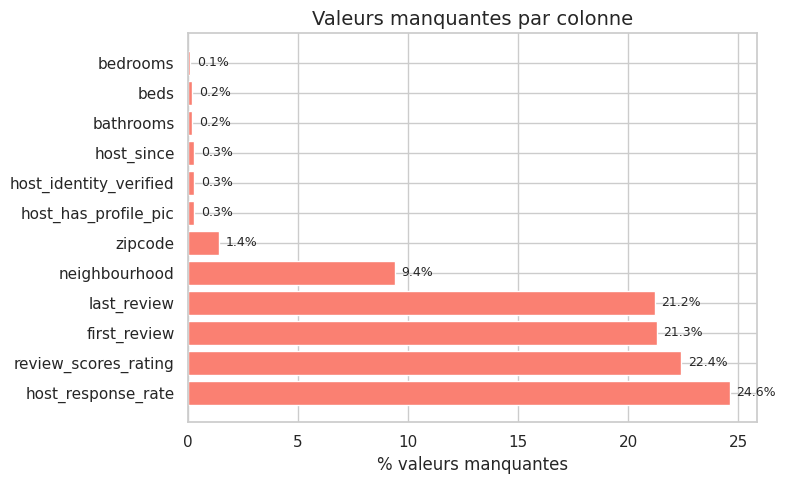

In [155]:
missing=airbnb.isnull().sum()
missing_pourcent=(missing/len(airbnb)*100).round(1) #calcul du pourcentage de valeurs manquantes
missing_dataframe=pd.DataFrame({'nb de valeurs manquantes' : missing, '%':missing_pourcent}) #nouveau DataFrame pour visualiser les valeurs manquantes
missing_dataframe=missing_dataframe[missing_dataframe['nb de valeurs manquantes']>0].sort_values('%', ascending=False)

#graphe pour rendre les observations plus visuelles
fig, axes=plt.subplots(figsize=(8,5))
graphe_barres=axes.barh(missing_dataframe.index, missing_dataframe['%'], color='salmon',edgecolor='white')
axes.set_xlabel('% valeurs manquantes')
axes.set_title('Valeurs manquantes par colonne', fontsize=14)
for barre, valeur in zip(graphe_barres, missing_dataframe['%']):
    axes.text(barre.get_width()+0.3, barre.get_y()+barre.get_height()/2,f'{valeur}%',va='center', fontsize=9) #ajout du texte à côté de chaque barre
plt.tight_layout() #ajustement des espacements pour la lisibilité
plt.show()

On ne peut pas déduire de ce graphique la suppression ou non des colonnes dont le pourcentage de valeurs nulles est supérieur à 20%.

### Affichage de statistiques génériques (count, moyenne, écart-type, nombre d'élements uniques...)

In [156]:
airbnb.describe(include="all")

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
count,2.223400e+04,22234.000000,22234,22234,22234,22234.000000,22183.000000,22234,22234,22234,22234,17509,22178,22178,16759,22178,22234,17518,22234.000000,22234.000000,22234,20148,22234.000000,17256.000000,21931,22208.000000,22199.000000
unique,NaN,NaN,31,3,21160,NaN,NaN,5,5,2,6,2096,2,2,70,2852,2,1042,NaN,NaN,22155,558,NaN,NaN,674,NaN,NaN
top,NaN,NaN,Apartment,Entire home/apt,{},NaN,NaN,Real Bed,strict,True,NYC,2017-01-01,t,t,100%,2015-03-30,f,2017-04-30,NaN,NaN,East Village Studio,Williamsburg,NaN,NaN,11211.0,NaN,NaN
freq,NaN,NaN,14635,12348,161,NaN,NaN,21622,9726,16401,9739,88,22108,14953,13048,68,16401,420,NaN,NaN,4,878,NaN,NaN,425,NaN,NaN
mean,1.122269e+07,4.783481,NaN,NaN,NaN,3.155573,1.236037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.462971,-92.269305,NaN,NaN,20.670774,94.069077,NaN,1.264769,1.711473
std,6.080480e+06,0.718758,NaN,NaN,NaN,2.143870,0.586246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.071679,21.670081,NaN,NaN,37.183731,7.782235,NaN,0.852819,1.254903
min,3.362000e+03,2.302585,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.339002,-122.510940,NaN,NaN,0.000000,20.000000,NaN,0.000000,0.000000
25%,6.202924e+06,4.317488,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.136082,-118.340633,NaN,NaN,1.000000,92.000000,NaN,1.000000,1.000000
50%,1.217425e+07,4.700480,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.662632,-76.994944,NaN,NaN,6.000000,96.000000,NaN,1.000000,1.000000
75%,1.639502e+07,5.220356,NaN,NaN,NaN,4.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.746358,-73.954599,NaN,NaN,23.000000,100.000000,NaN,1.000000,2.000000


### Fréquence d'apparition des valeurs dites 'top' dans les colonnes éligibles (sans compter les valeurs nulles)

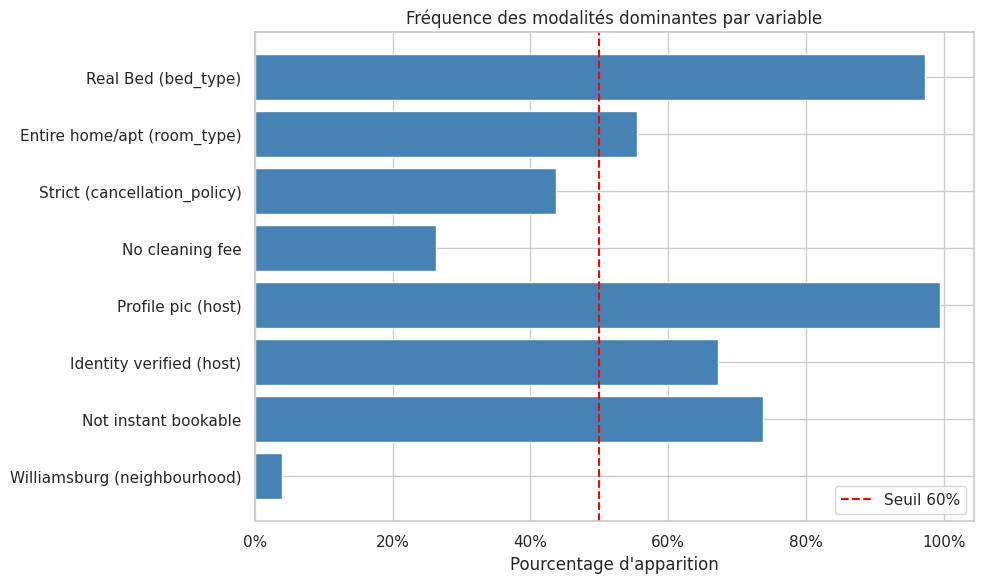

In [157]:
data = {
    "Real Bed (bed_type)":               (airbnb['bed_type'] == 'Real Bed').mean(),
    "Entire home/apt (room_type)":        (airbnb['room_type'] == 'Entire home/apt').mean(),
    "Strict (cancellation_policy)":       (airbnb['cancellation_policy'] == 'strict').mean(),
    "No cleaning fee":                    (airbnb['cleaning_fee'] == False).mean(),
    "Profile pic (host)":                 (airbnb['host_has_profile_pic'] == 't').mean(),
    "Identity verified (host)":           (airbnb['host_identity_verified'] == 't').mean(),
    "Not instant bookable":               (airbnb['instant_bookable'] == 'f').mean(),
    "Williamsburg (neighbourhood)":       (airbnb['neighbourhood'] == 'Williamsburg').mean(),
}

labels = list(data.keys())
values = list(data.values())

# Graphique
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(labels, values, color='steelblue')
ax.axvline(x=0.5, color='red', linestyle='--', label='Seuil 60%')
ax.set_xlabel("Pourcentage d'apparition")
ax.set_title("Fréquence des modalités dominantes par variable")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.show()


On remarque que certains pourcentages sont très importants : on peut supposer qu'elles n'ont pas d'influence notable sur le prix. On décide donc de supprimer toutes les colonnes dont la principale valeur compose 20% de la colonne.

In [158]:
airbnb.drop(["bed_type", "host_has_profile_pic", "instant_bookable"], axis=1, inplace=True)

## Analyse des variables numériques

### Distribution des prix

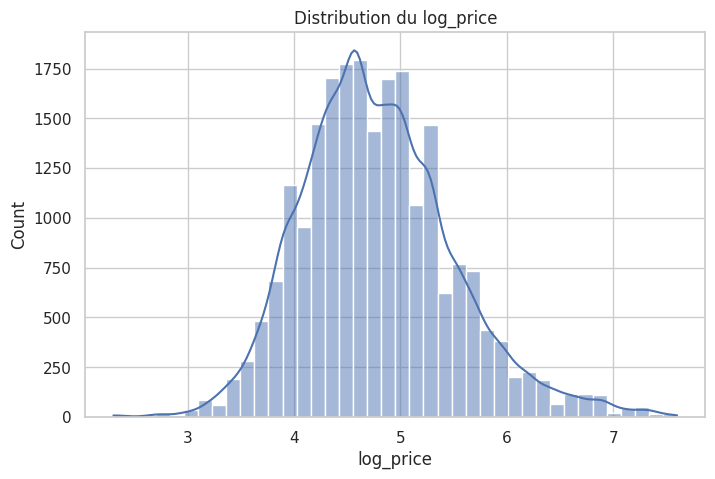

In [159]:
plt.figure(figsize=(8,5))
sns.histplot(airbnb['log_price'], bins=40, kde=True)
plt.title("Distribution du log_price")
plt.show()

On observe que la variable `log_price` suit une distribution relativement proche d’une loi normale.

### Influence de la ville sur le prix

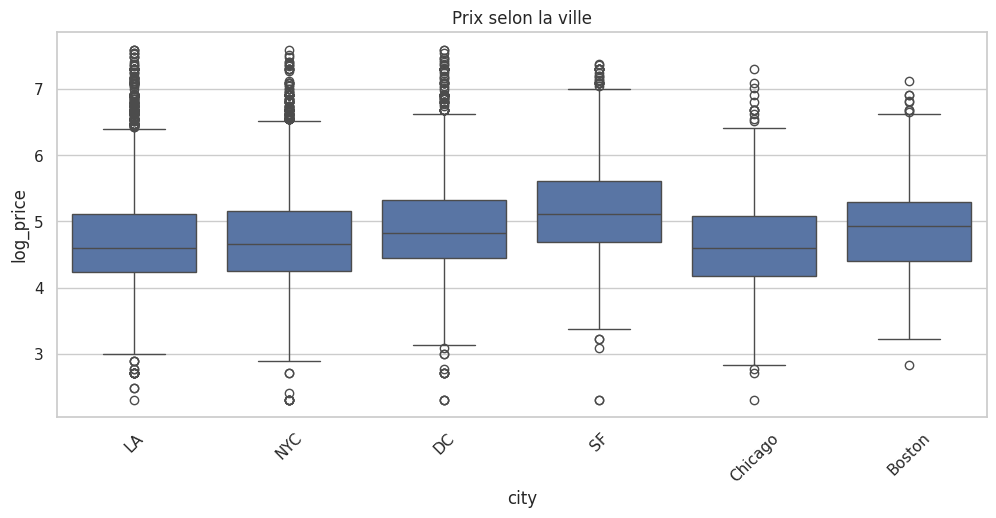

In [160]:
plt.figure(figsize=(12,5))
sns.boxplot(data=airbnb, x='city', y='log_price')
plt.xticks(rotation=45)
plt.title("Prix selon la ville")
plt.show()

Ce graphique montre que le prix des logements varie fortement selon la ville.

Certaines villes présentent :
- une médiane de prix plus élevée
- une plus grande dispersion des prix
- davantage de logements très chers

La variable `city` semble donc être une caractéristique importante pour prédire le prix d’un logement Airbnb.

Cela justifie sa conservation dans le modèle de prédiction.

### Corrélations entre variables numériques

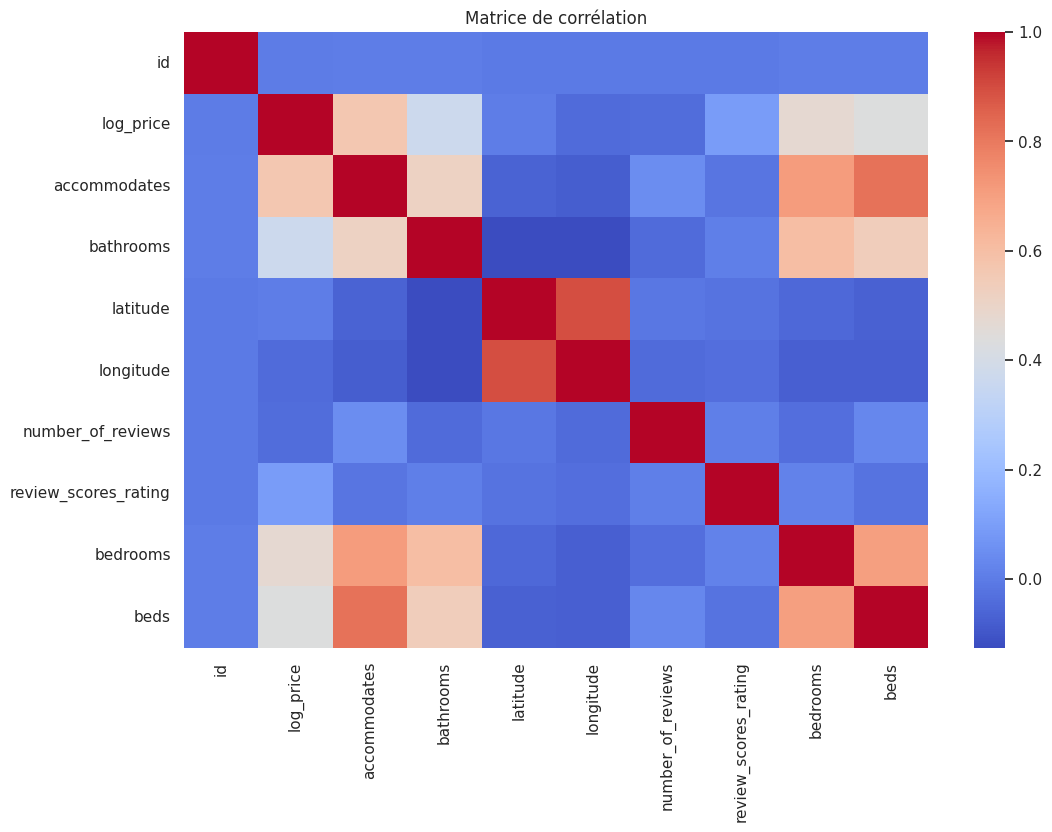

In [161]:
numeric_cols = airbnb.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()

La matrice de corrélation permet d’identifier les relations entre les différentes variables numériques.

On observe notamment que certaines caractéristiques comme :
- le nombre de personnes accueillies (`accommodates`)
- le nombre de chambres
- le nombre de lits

semblent positivement corrélées avec le prix du logement.

### Relation entre capacité d’accueil et prix

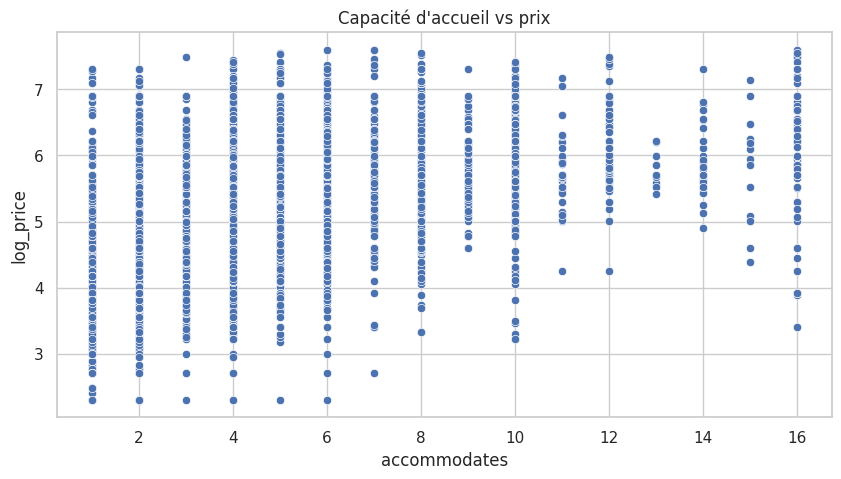

In [162]:
sns.scatterplot(data=airbnb, x='accommodates', y='log_price')
plt.title("Capacité d'accueil vs prix")
plt.show()

On observe une tendance générale : plus un logement peut accueillir de personnes, plus son prix augmente.

La relation n’est cependant pas parfaitement linéaire, ce qui laisse penser que d'autres variables sont liées de façon non linéaire au prix.


Cette variable reste néanmoins pertinente pour la prédiction.

# Entraînement

### Remplacer le type de propriété par un indice, cela permet à l’algo de l’utiliser

In [163]:
class CustomTransformation():

    rooms = airbnb["room_type"].unique()
    cancellation = airbnb["cancellation_policy"].unique()
    verified = airbnb["host_identity_verified"].unique()
    cities = airbnb["city"].unique()
    properties = airbnb["property_type"].unique()

    def __init__(self):
        """
        Class simple pour convertir les type de propriétés en des indices numériques, utilisable pour un algo de machine learning
        """

        self.fitted = False # Indique si fit_transform a été utilisé, pour éviter d’utiliser transform sans que fit ait été appelé
        self.property2index = dict()# Dictionnaire qui va convertir le nom en indice
        self.rooms2index = dict()
        self.cancel2index = dict()
        self.online2index = dict()
        self.cities2index = dict()

        self.tf2index = {'t':True, 'f':False}

        self.max_index_prop = 0 # Indique le dernier indice de la propriété.
        self.max_index_rooms = 0
        self.max_index_cancel = 0
        self.max_index_cities = 0

    def fit_transform(self, dataset):
        self.fitted = True

        # Calcul des mappings uniquement
        self.property2index = {prop:i for (i, prop) in enumerate(self.properties)}
        self.max_index_prop = max(list(self.property2index.values()))

        self.rooms2index = {r:i for (i, r) in enumerate(self.rooms)}
        self.max_index_rooms = max(list(self.rooms2index.values()))

        self.cancel2index = {can:i for (i, can) in enumerate(self.cancellation)}
        self.max_index_cancel = max(list(self.cancel2index.values()))

        self.cities2index = {cit:i for (i, cit) in enumerate(self.cities)}
        self.max_index_cities = max(list(self.cities2index.values()))

        # Calcul des top amenities (fit uniquement)
        dataset['amenities_list'] = dataset['amenities'].apply(_parse_amenities)
        all_items = [item for lst in dataset['amenities_list'] for item in lst]
        self.top_amenities = [item for item, _ in Counter(all_items).most_common(30)]
        dataset.drop('amenities_list', axis=1, inplace=True)

        # Tout le reste est fait dans transform
        return self.transform(dataset)

    def transform(self, dataset):
        # Transform les propriétés en indice
        dataset.loc[:, "property_type"] = dataset["property_type"].replace(self.property2index)
        dataset.loc[:, "room_type"] = dataset["room_type"].replace(self.rooms2index)
        dataset.loc[:, "cancellation_policy"] = dataset["cancellation_policy"].replace(self.cancel2index)
        dataset.loc[:, "city"] = dataset["city"].replace(self.cities2index)
        dataset.loc[:, "property_type"] = dataset["property_type"].replace(self.property2index)

        dataset.loc[:, "host_identity_verified"] = dataset["host_identity_verified"].replace(self.tf2index)

        # Même traitement que fit_transform, mais sans recalculer les top amenities
        dataset['amenities_list'] = dataset['amenities'].apply(_parse_amenities)
        dataset['amenities_count'] = dataset['amenities_list'].apply(len)

        for amenity in self.top_amenities:
            col = 'amenity_' + amenity.replace(' ', '_').replace('/', '_')
            dataset[col] = dataset['amenities_list'].apply(lambda lst: int(amenity in lst))

        dataset.drop('amenities_list', axis=1, inplace=True)


         # Ligne un peu moche qui fait en sorte de remplacer les lignes qui ont des noms de logement qui n’était pas dans l’entrainement
        dataset.loc[dataset["property_type"].map(type).eq(str), "property_type"] = np.nan


        # remplace les valeurs null
        dataset[dataset.bathrooms.isna()] = 0
        dataset[dataset.accommodates.isna()] = 0
        dataset[dataset.property_type.isna()] = self.max_index_prop + 1
        dataset[dataset.room_type.isna()] = self.max_index_rooms + 1
        dataset[dataset.cancellation_policy.isna()] = self.max_index_cancel + 1
        dataset[dataset.city.isna()] = self.max_index_cities + 1

        # Conversion des dates en nombre de jours
        ref = pd.Timestamp('2017-01-01')
        for col in ['host_since', 'first_review', 'last_review']:
            if col in dataset.columns:
                dataset[col] = pd.to_datetime(dataset[col], errors='coerce')
                dataset[col + '_days'] = (ref - dataset[col]).dt.days
                dataset[col + '_days'] = dataset[col + '_days'].fillna(dataset[col + '_days'].median())
                dataset.drop(col, axis=1, inplace=True)


        return dataset

In [164]:
features_transformer = CustomTransformation()

airbnb.head()
airbnb_train = features_transformer.fit_transform(airbnb)
airbnb_train.head()

/tmp/ipykernel_3279/541446227.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.loc[:, "property_type"] = dataset["property_type"].replace(self.property2index)
/tmp/ipykernel_3279/541446227.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.loc[:, "room_type"] = dataset["room_type"].replace(self.rooms2index)
/tmp/ipykernel_3279/541446227.py:57: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_object

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,cancellation_policy,cleaning_fee,city,host_identity_verified,host_response_rate,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds,amenities_count,amenity_kitchen,amenity_heating,amenity_wireless_internet,amenity_smoke_detector,amenity_essentials,amenity_air_conditioning,amenity_[tv,amenity_hangers,amenity_carbon_monoxide_detector,amenity_shampoo,amenity_washer,amenity_dryer,amenity_hair_dryer,amenity_iron,amenity_family_kid_friendly,amenity_internet,amenity_fire_extinguisher,amenity_laptop_friendly_workspace,amenity_first_aid_kit,amenity_free_parking_on_premises,amenity_cable_tv,amenity_translation_missing:_en.hosting_amenity_49,amenity_24-hour_check-in,amenity_lock_on_bedroom_door,amenity_buzzer_wireless_intercom,amenity_translation_missing:_en.hosting_amenity_50],amenity_laptop_friendly_workspace],amenity_safety_card,amenity_self_check-in,amenity_elevator,host_since_days,first_review_days,last_review_days
0,5708593,4.317488,0,0,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,0,False,0,False,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0,15,1,0,1,1,1,0,1,1,0,1,1,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,386.0,220.0,-117.0
1,14483613,4.007333,0,0,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,1,False,1,True,100%,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0,25,1,1,0,1,1,1,0,0,1,0,0,0,1,1,1,0,1,0,0,0,0,0,1,1,0,0,0,0,1,0,58.0,-126.0,-259.0
2,10412649,7.090077,1,1,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,0,False,2,False,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0,20,1,1,1,1,1,1,1,0,1,1,1,1,0,0,1,0,1,0,1,1,0,0,0,1,0,0,1,1,0,0,21.0,220.0,-117.0
3,17954362,3.555348,0,0,"{TV,""Cable TV"",Internet,""Wireless Internet"",""A...",1,1.0,0,True,1,True,100%,40.736001,-73.924248,Manhattan view from Queens. Lovely single room .,Sunnyside,19,96.0,11104,1.0,1.0,30,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,1611.0,86.0,-271.0
4,9969781,5.480639,0,1,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,2,True,3,True,100%,37.744896,-122.430665,Zen Captured Noe Valley House,Noe Valley,15,96.0,94131,2.0,2.0,24,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,0,1,1,1,1,0,1,0,0,0,0,1,1,0,1256.0,98.0,-239.0


## Vérification du dataset

Avant d'entraîner l'algorithme, on souhaite d'abord vérifier qu'il n'y a pas de problème dans le dataset. On vérifie d'abord le résumé de notre dataframe.

In [165]:
airbnb_train.describe(include='all')

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,cancellation_policy,cleaning_fee,city,host_identity_verified,host_response_rate,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds,amenities_count,amenity_kitchen,amenity_heating,amenity_wireless_internet,amenity_smoke_detector,amenity_essentials,amenity_air_conditioning,amenity_[tv,amenity_hangers,amenity_carbon_monoxide_detector,amenity_shampoo,amenity_washer,amenity_dryer,amenity_hair_dryer,amenity_iron,amenity_family_kid_friendly,amenity_internet,amenity_fire_extinguisher,amenity_laptop_friendly_workspace,amenity_first_aid_kit,amenity_free_parking_on_premises,amenity_cable_tv,amenity_translation_missing:_en.hosting_amenity_49,amenity_24-hour_check-in,amenity_lock_on_bedroom_door,amenity_buzzer_wireless_intercom,amenity_translation_missing:_en.hosting_amenity_50],amenity_laptop_friendly_workspace],amenity_safety_card,amenity_self_check-in,amenity_elevator,host_since_days,first_review_days,last_review_days
count,2.223400e+04,22234.000000,22234.0,22234.0,22234,22234.000000,22234.000000,22234.0,22234,22234.0,22178,16774,22234.000000,22234.000000,22234.0,20149,22234.000000,17264.000000,21931,22208.000000,22208.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000
unique,NaN,NaN,31.0,3.0,21119,NaN,NaN,5.0,2,6.0,2,71,NaN,NaN,22105.0,559,NaN,NaN,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,1.0,1.0,{},NaN,NaN,1.0,True,1.0,True,100%,NaN,NaN,0.0,Williamsburg,NaN,NaN,11211.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,14601.0,12328.0,158,NaN,NaN,9702.0,16377,9713.0,14917,13026,NaN,NaN,51.0,878,NaN,NaN,425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.119351e+07,4.772788,NaN,NaN,NaN,3.150040,1.233201,NaN,NaN,NaN,NaN,NaN,38.374410,-92.063793,NaN,NaN,20.595125,93.795181,NaN,1.262068,1.708438,17.629351,0.902222,0.898669,0.840155,0.831294,0.818386,0.738104,0.707520,0.646712,0.633444,0.605109,0.584690,0.566880,0.567194,0.517361,0.501349,0.477782,0.409598,0.386570,0.368670,0.317667,0.311820,0.254070,0.252811,0.240982,0.233156,0.230233,0.200189,0.156652,0.149816,0.146083,891.679230,321.439417,-83.371953
std,6.097074e+06,0.753662,NaN,NaN,NaN,2.147838,0.588551,NaN,NaN,NaN,NaN,NaN,3.577633,22.092124,NaN,NaN,37.134816,9.299268,NaN,0.854497,1.256803,7.005426,0.297021,0.301774,0.366471,0.374500,0.385535,0.439676,0.454912,0.478002,0.481875,0.488838,0.492786,0.495518,0.495475,0.499710,0.500009,0.499517,0.491771,0.486975,0.482455,0.465580,0.463247,0.435347,0.434633,0.427689,0.422851,0.420991,0.400151,0.363481,0.356899,0.353197,660.092184,440.517584,204.559348
min,0.000000e+00,0.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-122.510940,NaN,NaN,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-276.000000,-274.000000,-277.000000
25%,6.145774e+06,4.304065,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,NaN,NaN,34.132370,-118.340275,NaN,NaN,1.000000,92.000000,NaN,1.000000,1.000000,13.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.0

On remarque que la colonne `host_response_rate` est systématiquement à 100% et n'apporte rien au dataset. De la même façon, la colonne `review_score_rating` n'a pas un impact significatif puisque le premier et le dernier quantile sont très rapprochés (92 et 100). On décide donc de les drop. 

In [166]:
airbnb.drop(["host_response_rate"], axis=1, inplace=True)
airbnb.drop(["review_scores_rating"], axis=1, inplace=True)

On veut vérifier l'impact des colonnes `amenities` sur la prédiction du prix. Pour ce faire, on crée un tableau contenant tous les noms commençant par 'amenity' et le prix pour lequel on va afficher la matrice de corrélation.

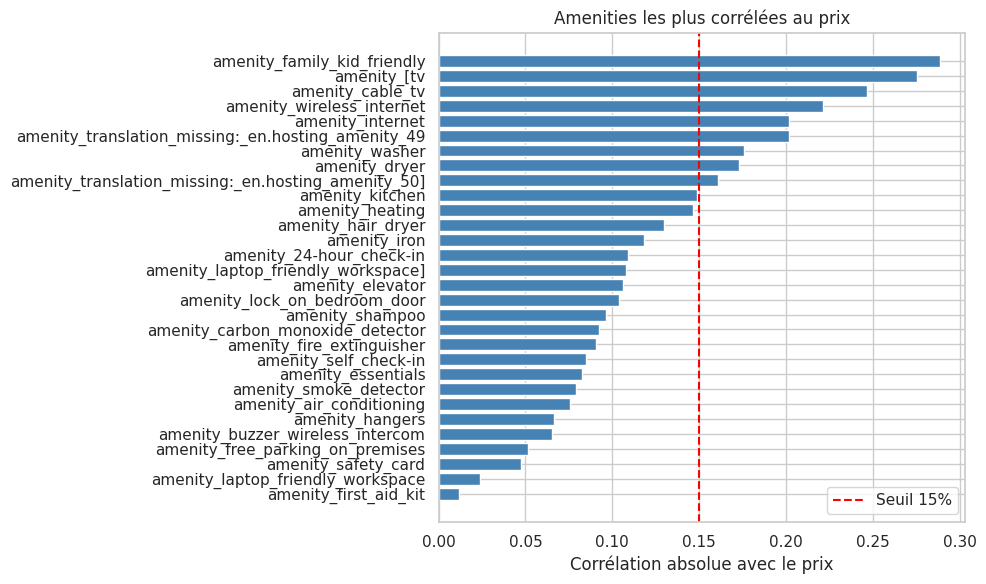

In [190]:
amenities = airbnb.filter(regex='^amenity') #prend toutes les colonnes qui commencent par 'amenity'
amenities = amenities.assign(price=airbnb['log_price'])

correlations = amenities.corr()['price'].drop('price')
correlations_triees = correlations.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(correlations_triees.index, correlations_triees.values, color='steelblue')
ax.axvline(x=0.15, color='red', linestyle='--', label='Seuil 15%')
ax.set_xlabel('Corrélation absolue avec le prix')
ax.set_title('Amenities les plus corrélées au prix')
ax.invert_yaxis()  # la plus forte corrélation en haut
ax.legend()
plt.tight_layout()
plt.show()

On garde donc les corrélations au-dessus du seuil fixé.

In [191]:
to_keep = correlations_triees[correlations_triees > 0.15]
names_to_keep = to_keep.index.to_list()
print(names_to_keep)

['amenity_family_kid_friendly', 'amenity_[tv', 'amenity_cable_tv', 'amenity_wireless_internet', 'amenity_internet', 'amenity_translation_missing:_en.hosting_amenity_49', 'amenity_washer', 'amenity_dryer', 'amenity_translation_missing:_en.hosting_amenity_50]']


On décide ensuite de vérifier si les colonnes sélectionnées sont correctement conditionnées (i.e. si elles ne sont pas constantes).

In [192]:
selected_amenities = amenities[names_to_keep]
selected_amenities.describe()

,amenity_family_kid_friendly,amenity_[tv,amenity_cable_tv,amenity_wireless_internet,amenity_internet,amenity_translation_missing:_en.hosting_amenity_49,amenity_washer,amenity_dryer,amenity_translation_missing:_en.hosting_amenity_50]
count,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000,22234.000000
mean,0.501349,0.707520,0.311820,0.840155,0.477782,0.254070,0.584690,0.566880,0.230233
std,0.500009,0.454912,0.463247,0.366471,0.499517,0.435347,0.492786,0.495518,0.420991
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


On remarque que pour les les colonnes `amenity_translation_missing:_en.hosting_amenity_49` et `amenity_translation_missing:_en.hosting_amenity_50]`, plus de 50% des valeurs sont égales à 0. On décide donc de les drop.

In [ ]:
names_to_keep.remove('amenity_translation_missing:_en.hosting_amenity_49')
names_to_keep.remove('amenity_translation_missing:_en.hosting_amenity_50]')

## Sélection des features

In [194]:
class FeatureSelection():

    def __init__(self):
        """
        Class simple pour juste garder les colonnes qui nous intéresse
        N'a pas forcément l'air nécessaire, mais c'est pour être sur que j'applique bien le même process au train et au test
        """

    def fit_transform(self, dataset, y=None):
        return self.transform(dataset)

    def transform(self, dataset):
        cols = [
            # Taille du logement
            "accommodates", "bathrooms", "bedrooms", "beds",

            # Type de logement
            "property_type", "room_type", 

            # Localisation
            "city", "latitude", "longitude",

            # Conditions
            "cancellation_policy", "cleaning_fee",

            # Hôte
            "host_identity_verified",

            # Avis
            "number_of_reviews",

            "host_since_days", "first_review_days", "last_review_days"
        ]

        # on garde que les colonnes qui existent réellement
        cols = [c for c in cols if c in dataset.columns]
        new_dataset = dataset[cols].copy()
        # Récupère automatiquement toutes les colonnes amenity_* créées
        amenity_cols = [c for c in dataset.columns if c in names_to_keep]
        cols += amenity_cols
        for a in amenity_cols:
            new_dataset[a] = dataset[a]

        for col in new_dataset.columns:
            
            new_dataset[col] = pd.to_numeric(new_dataset[col], errors='coerce').fillna(0)
        return new_dataset


feature_selector = FeatureSelection()

airbnb_train = feature_selector.transform(airbnb)
airbnb_train.head()

,accommodates,bathrooms,bedrooms,beds,property_type,room_type,city,latitude,longitude,cancellation_policy,cleaning_fee,host_identity_verified,number_of_reviews,host_since_days,first_review_days,last_review_days,amenity_wireless_internet,amenity_[tv,amenity_washer,amenity_dryer,amenity_family_kid_friendly,amenity_internet,amenity_cable_tv,amenity_translation_missing:_en.hosting_amenity_49,amenity_translation_missing:_en.hosting_amenity_50]
0,3,1.0,0.0,2.0,0,0,0,33.782712,-118.134410,0,0,0.0,0,386.0,220.0,-117.0,1,1,1,1,0,0,0,0,0
1,4,2.0,1.0,2.0,0,0,1,40.705468,-73.909439,1,0,1.0,38,58.0,-126.0,-259.0,0,0,0,0,1,0,0,0,0
2,6,2.0,2.0,2.0,1,1,2,38.917537,-77.031651,0,0,0.0,0,21.0,220.0,-117.0,1,1,1,1,1,0,0,0,0
3,1,1.0,1.0,1.0,0,0,1,40.736001,-73.924248,0,1,1.0,19,1611.0,86.0,-271.0,1,1,0,0,1,1,1,0,0
4,4,1.0,2.0,2.0,0,1,3,37.744896,-122.430665,2,1,1.0,15,1256.0,98.0,-239.0,1,1,1,1,1,1,1,0,0


## Apprentissage

In [195]:
from sklearn.model_selection import train_test_split

# Vous avez le droit d’utiliser les Pipeline et transform de sklearn :
# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
features_transformer = CustomTransformation()
feature_selector = FeatureSelection()

airbnb = pd.read_csv("data/airbnb_train.csv")

airbnb_train = features_transformer.fit_transform(airbnb)
airbnb_train = feature_selector.transform(airbnb_train)

X = airbnb_train.copy()
y = airbnb["log_price"]

# train cross validation
X_train, X_test, y_train, y_test = train_test_split(X, y)

/tmp/ipykernel_3279/541446227.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.loc[:, "property_type"] = dataset["property_type"].replace(self.property2index)
/tmp/ipykernel_3279/541446227.py:56: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset.loc[:, "room_type"] = dataset["room_type"].replace(self.rooms2index)
/tmp/ipykernel_3279/541446227.py:57: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_object

### Modèle 1 : LinearSVR()

Le score R2 est un score de regression, il vaut 1 si la prédiction est parfaite, 0 si la valeur prédite est la moyenne de $y$. Et des scores négatifs si la prédiction est moins bonne que prédire la moyenne (donc vraiment mauvais)

In [196]:
from sklearn.svm import LinearSVR
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_train = scaler.fit_transform(X_train.to_numpy())
X_scaled_test = scaler.fit_transform(X_test.to_numpy())


model = LinearSVR(max_iter=10_000, C=0.1, epsilon=0.5)

model.fit(X_scaled_train, y_train)

y_pred_train = model.predict(X_scaled_train)
y_pred_test = model.predict(X_scaled_test)


print(f"Score en entrainenement : {r2_score(y_true=y_train, y_pred=y_pred_train)}")
print(f"Score en cross validation : {r2_score(y_true=y_test, y_pred=y_pred_test)}")


Score en entrainenement : 0.4873370263780532
Score en cross validation : 0.48556441200353295


Ci-dessous se trouve un code qui permet de trouver les valeurs optimales pour C et Epsilon afin d'améliorer les performances du modèle.

In [197]:
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
import numpy as np


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', LinearSVR(
        max_iter=10_000,     
        dual=True,           
        tol=1e-4             
    ))
])

param_grid = {
    'svr__C': [0.01, 0.1, 1, 10, 100],
    'svr__epsilon': [0.0, 0.1, 0.5, 1.0]  # marge d'insensibilité
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print(f"Meilleurs params     : {grid.best_params_}")
print(f"Meilleur R² (CV)     : {grid.best_score_:.4f}")

best_model = grid.best_estimator_
y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

print(f"R² entraînement      : {r2_score(y_train, y_pred_train):.4f}")
print(f"R² test              : {r2_score(y_test,  y_pred_test):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Meilleurs params     : {'svr__C': 0.1, 'svr__epsilon': 0.5}
Meilleur R² (CV)     : 0.4851
R² entraînement      : 0.4873
R² test              : 0.4848


#### Analyse des erreurs du modèle

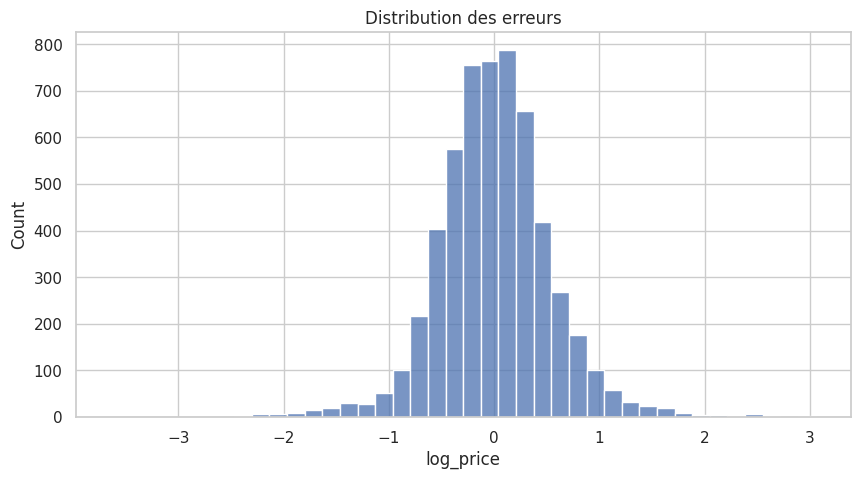

In [ ]:
errors = y_test - y_pred_test

sns.histplot(errors, bins=40)
plt.title("Distribution des erreurs")
plt.show()

La distribution des erreurs permet d’évaluer la qualité globale du modèle.

Un bon modèle produit généralement :
- des erreurs centrées autour de zéro
- une distribution relativement symétrique
- peu de valeurs extrêmes

Les erreurs importantes peuvent correspondre à des logements atypiques ou à des informations insuffisantes dans les données.

#### Comparaison entre valeurs réelles et prédictions

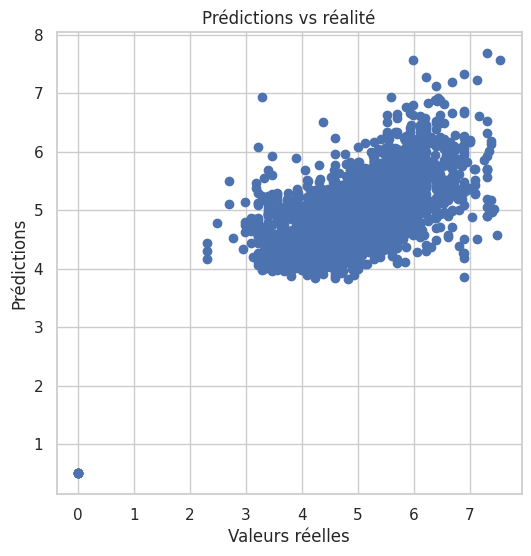

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_test)
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Prédictions vs réalité")
plt.show()

Ce graphique compare les valeurs réelles aux prédictions du modèle.

Si les prédictions étaient parfaites, tous les points seraient alignés sur une diagonale.

On observe ici que le modèle capture correctement la tendance générale mais présente encore certaines erreurs sur des logements particuliers.

### Modèle 2 : Random Forest

Le Random Forest est un modèle ensembliste : il entraîne plusieurs arbres de décision sur des sous-ensembles aléatoires du dataset et fait la moyenne de leurs prédictions. 

Avantages : robuste aux valeurs aberrantes, capture les relations non-linéaires, pas besoin de normaliser les données.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=200,   # nombre d'arbres
    max_depth=15,       # profondeur maximum de chaque arbre
    random_state=42,
    n_jobs=-1           # utilise tous les coeurs disponibles
)

rf.fit(X_train, y_train)

y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf  = rf.predict(X_test)

r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf  = r2_score(y_test,  y_pred_test_rf)
rmse_rf     = np.sqrt(mean_squared_error(y_test, y_pred_test_rf))

print(f"Random Forest — R² train : {r2_train_rf:.4f}")
print(f"Random Forest — R² test  : {r2_test_rf:.4f}")
print(f"Random Forest — RMSE     : {rmse_rf:.4f}")

Random Forest — R² train : 0.9118
Random Forest — R² test  : 0.6869
Random Forest — RMSE     : 0.4100


#### Analyse des erreurs

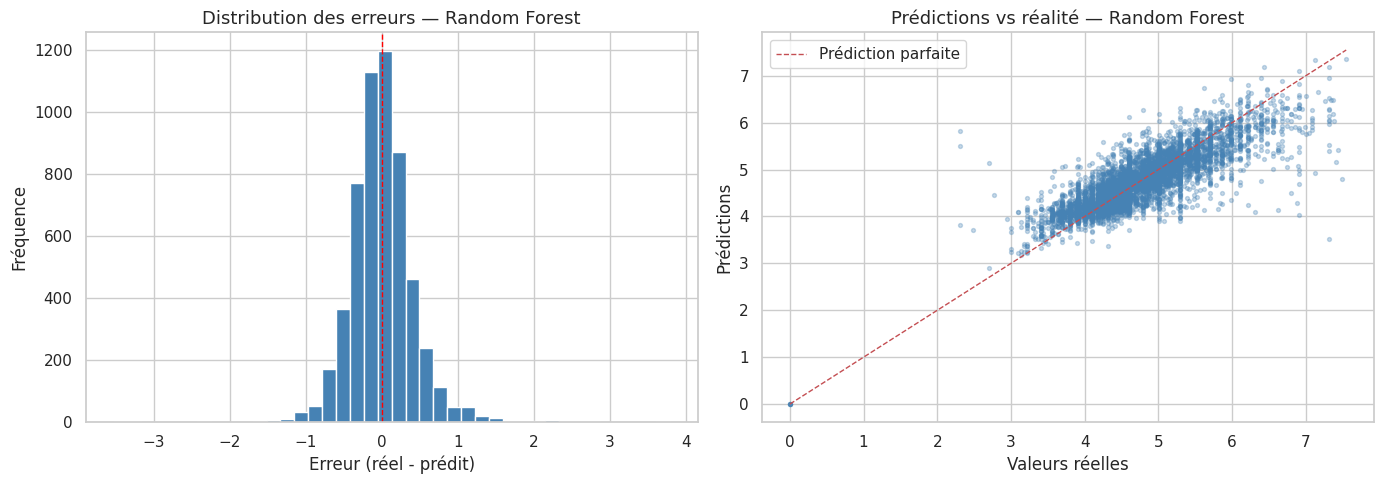

In [ ]:
errors_rf = y_test - y_pred_test_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors_rf, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title("Distribution des erreurs — Random Forest", fontsize=13)
axes[0].set_xlabel("Erreur (réel - prédit)")
axes[0].set_ylabel("Fréquence")

axes[1].scatter(y_test, y_pred_test_rf, alpha=0.3, s=8, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1, label='Prédiction parfaite')
axes[1].set_title("Prédictions vs réalité — Random Forest", fontsize=13)
axes[1].set_xlabel("Valeurs réelles")
axes[1].set_ylabel("Prédictions")
axes[1].legend()

plt.tight_layout()
plt.show()

### Modèle 3 : Gradient Boosting

Le Gradient Boosting entraîne les arbres séquentiellement : chaque arbre corrige les erreurs du précédent.
C'est souvent le modèle le plus performant sur des données tabulaires.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
 
gb = GradientBoostingRegressor(
    n_estimators=200,   # nombre d'arbres
    learning_rate=0.1,  # taux d'apprentissage
    max_depth=5,        # profondeur max de chaque arbre
    random_state=42
)
 
gb.fit(X_train, y_train)
 
y_pred_train_gb = gb.predict(X_train)
y_pred_test_gb  = gb.predict(X_test)
 
r2_train_gb = r2_score(y_train, y_pred_train_gb)
r2_test_gb  = r2_score(y_test,  y_pred_test_gb)
rmse_gb     = np.sqrt(mean_squared_error(y_test, y_pred_test_gb))
 
print(f"Gradient Boosting — R² train : {r2_train_gb:.4f}")
print(f"Gradient Boosting — R² test  : {r2_test_gb:.4f}")
print(f"Gradient Boosting — RMSE     : {rmse_gb:.4f}")

Gradient Boosting — R² train : 0.8070
Gradient Boosting — R² test  : 0.7117
Gradient Boosting — RMSE     : 0.3934


#### Analyse du Gradient Boosting

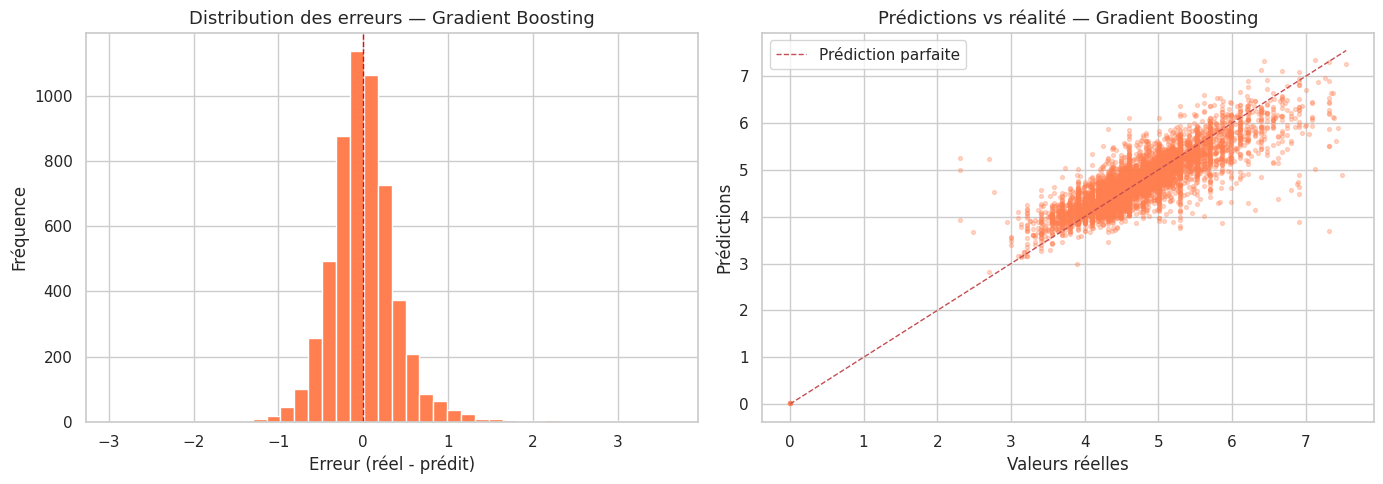

In [ ]:
errors_gb = y_test - y_pred_test_gb
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].hist(errors_gb, bins=40, color='coral', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title("Distribution des erreurs — Gradient Boosting", fontsize=13)
axes[0].set_xlabel("Erreur (réel - prédit)")
axes[0].set_ylabel("Fréquence")
 
axes[1].scatter(y_test, y_pred_test_gb, alpha=0.3, s=8, color='coral')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1, label='Prédiction parfaite')
axes[1].set_title("Prédictions vs réalité — Gradient Boosting", fontsize=13)
axes[1].set_xlabel("Valeurs réelles")
axes[1].set_ylabel("Prédictions")
axes[1].legend()
 
plt.tight_layout()
plt.show()

### Comparaison de tous les modèles

In [ ]:
r2_svr  = r2_score(y_test, best_model.predict(X_test))   # LinearSVR avec GridSearch
rmse_svr = np.sqrt(mean_squared_error(y_test, best_model.predict(X_test)))
 
resultats = pd.DataFrame({
    'Modèle': ['LinearSVR (GridSearch)', 'Random Forest', 'Gradient Boosting'],
    'R² test': [r2_svr, r2_test_rf, r2_test_gb],
    'RMSE test': [rmse_svr, rmse_rf, rmse_gb]
})
 
print(resultats.to_string(index=False))


                Modèle  R² test  RMSE test
LinearSVR (GridSearch) 0.452157   0.542346
         Random Forest 0.686864   0.410029
     Gradient Boosting 0.711704   0.393430


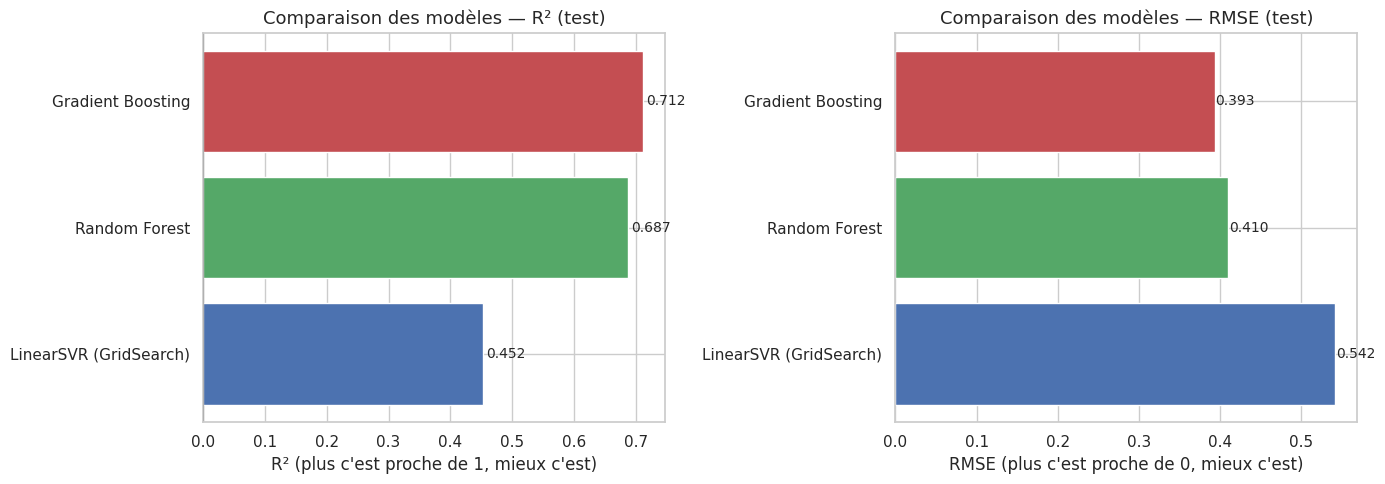

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
colors = ['#4C72B0', '#55A868', '#C44E52']
 
axes[0].barh(resultats['Modèle'], resultats['R² test'], color=colors, edgecolor='white')
axes[0].set_title('Comparaison des modèles — R² (test)', fontsize=13)
axes[0].set_xlabel('R² (plus c\'est proche de 1, mieux c\'est)')
axes[0].axvline(0, color='black', linewidth=0.8)
for i, val in enumerate(resultats['R² test']):
    axes[0].text(val + 0.005, i, f'{val:.3f}', va='center', fontsize=10)

axes[1].barh(resultats['Modèle'], resultats['RMSE test'], color=colors, edgecolor='white')
axes[1].set_title('Comparaison des modèles — RMSE (test)', fontsize=13)
axes[1].set_xlabel('RMSE (plus c\'est proche de 0, mieux c\'est)')
for i, val in enumerate(resultats['RMSE test']):
    axes[1].text(val + 0.001, i, f'{val:.3f}', va='center', fontsize=10)
 
plt.tight_layout()
plt.show()

On choisit de prendre le modèle `Gradient Boosting`, car il semble être celui dont l'erreur est la moins élevée.

In [ ]:
model = gb

## Prédiction sur le fichier de test

In [ ]:
airbnb_test = pd.read_csv("data/airbnb_test.csv")

# J’applique le même traitement que mon fichier entraînement
final_X_test = features_transformer.transform(airbnb_test)
final_X_test = feature_selector.transform(final_X_test)

final_X_test.tail()

FileNotFoundError: [Errno 2] No such file or directory: 'airbnb_test.csv'

In [ ]:
y_final_prediction = model.predict(final_X_test)
print(y_final_prediction)

## Sauvegarde dans le fichier de prédiction

In [ ]:
prediction_example = pd.read_csv("prediction_example.csv")
prediction_example["log_price"] = y_final_prediction

prediction_example.to_csv("MaPredictionFinale.csv", index=False) # index=False pour éviter d’ajouter l’index interne à pandas
# Voilà !

## Test de votre fichier

In [ ]:
def estConforme(monFichier_csv):
    votre_prediction = pd.read_csv(monFichier_csv)

    fichier_exemple = pd.read_csv("prediction_example.csv")

    assert votre_prediction.columns[1] == fichier_exemple.columns[1], f"Attention, votre colonne de prédiction doit s'appeler {fichier_exemple.columns[1]}, elle s'appelle '{votre_prediction.columns[1]}'"
    assert len(votre_prediction) == len(fichier_exemple), f"Attention, vous devriez avoir {len(fichier_exemple)} prédiction dans votre fichier, il en contient '{len(votre_prediction)}'"

    assert np.all(votre_prediction.iloc[:,0] == fichier_exemple.iloc[:, 0])

    print("Fichier conforme!")

estConforme("MaPredictionFinale.csv")

# Ce que je vais faire de mon côté

In [ ]:
# Vous n’avez pas accès à ce fichier, c’est normal, ce sont les vrais prédictions
# ===============================================================================
# true_test = pd.read_csv("../true_prediction.csv")
# ==========================================================

# votre_prediction = pd.read_csv("MaPredictionFinale.csv")["logpred"]
# print(r2_score(y_pred=votre_prediction, y_true=true_test["log_price"]))

# votre_prediction = pd.read_csv("prediction_example.csv")["logpred"] # Devrait avoir ~0
# print(r2_score(y_pred=votre_prediction, y_true=true_test["log_price"]))